
# pyunwrap: complete end-to-end pipeline

This notebook runs the **full chain**, start to finish:

1. **Synthetic data generation** -- realistic InSAR training scenes.
2. **Preprocessing & tiling** -- normalize and tile into an HDF5 dataset.
3. **Training** -- a short `AmbiguityNet` training run via `Trainer`.
4. **Tiled inference** -- `PhaseUnwrapper` on a full synthetic scene
   (written out as real GeoTIFFs, so this exercises the actual
   rasterio/tile-merging code path, not just in-memory arrays).
5. **Phase analytics** -- residue detection, Nyquist gradient analysis,
   error distribution (`pyunwrap.analytics.phase_stats`).
6. **Explainability** -- Grad-CAM and per-channel Integrated Gradients
   (`pyunwrap.analytics.explainability`).
7. **Visualization** -- an interactive 3D Plotly phase surface and an
   interactive folium comparison map.
8. **Automated HTML report** -- assembling everything above into one
   self-contained report via `pyunwrap.analytics.report_generator`.

As in the training notebook, scene/epoch counts are kept small here so the
whole chain runs in well under a minute on CPU; every step uses the real
package APIs at production scale semantics (just with a small `n`).


In [1]:

import math
import random
from pathlib import Path

import numpy as np
import torch
import rasterio
from rasterio.transform import from_origin
from IPython.display import IFrame, display, HTML

from pyunwrap.synthetic.generator import InSARSyntheticGenerator
from pyunwrap.data.preprocessing import (
    NormalizedRasters, iter_tiles, save_tiles_hdf5,
    normalize_phase, normalize_coherence, normalize_amplitude,
)
from pyunwrap.data.dataloader import InSARTileDataset
from pyunwrap.models.ambiguity_net import AmbiguityNet
from pyunwrap.training.trainer import Trainer
from pyunwrap.inference.unwrapper import PhaseUnwrapper
from pyunwrap.analytics import phase_stats, explainability
from pyunwrap.visualization import phase_plots
from pyunwrap.analytics.report_generator import generate_report

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

OUT_DIR = Path("nb_full_pipeline")
OUT_DIR.mkdir(exist_ok=True)
SCENE_SIZE = 128
print("Setup complete.")


Setup complete.


## 1-2. Synthetic data generation + preprocessing/tiling

In [2]:

def build_tile_dataset(path, n_scenes, size, tile_size, overlap, seed):
    gen = InSARSyntheticGenerator(size=size, seed=seed)
    deformation_types = ["gaussian_bowl", "mogi", "none"]
    all_tiles = []
    for i in range(n_scenes):
        deformation_type = deformation_types[i % len(deformation_types)]
        sample = gen.generate_sample(deformation_type=deformation_type)
        rasters = NormalizedRasters(
            wrapped_phase=normalize_phase(sample.wrapped_phase),
            coherence=normalize_coherence(sample.coherence),
            amplitude=normalize_amplitude(sample.amplitude),
        )
        tiles = list(iter_tiles(
            rasters, true_unwrapped=sample.unwrapped_phase,
            tile_size=tile_size, overlap=overlap,
        ))
        all_tiles.extend(tiles)
    save_tiles_hdf5(all_tiles, path)
    return len(all_tiles)

n_train = build_tile_dataset(OUT_DIR / "train.h5", n_scenes=8, size=SCENE_SIZE, tile_size=64, overlap=16, seed=SEED)
n_val = build_tile_dataset(OUT_DIR / "val.h5", n_scenes=2, size=SCENE_SIZE, tile_size=64, overlap=16, seed=SEED + 1000)
print(f"train tiles: {n_train}, val tiles: {n_val}")


train tiles: 72, val tiles: 18


## 3. Training

In [3]:

train_ds = InSARTileDataset(OUT_DIR / "train.h5", augment=True, require_ground_truth=True, seed=SEED)
val_ds = InSARTileDataset(OUT_DIR / "val.h5", augment=False, require_ground_truth=True, seed=SEED)

model = AmbiguityNet(pretrained=False, k_max=10.0)

trainer = Trainer(
    model=model, train_dataset=train_ds, val_dataset=val_ds,
    out_dir=OUT_DIR / "training_run", total_epochs=5, warmup_epochs=1,
    batch_size=4, num_workers=0, validate_every=5, device="cpu",
    use_curriculum=True,
)
trainer.fit()


[CurriculumIndex] WARNING: epoch 1's curriculum filter matched 0 tiles; falling back to the full dataset for this epoch to avoid stalling training.
[Trainer] Epoch 1: curriculum subset size = 72 / 72


[Trainer] Epoch 1/5 loss=20.1209 lr=1.00e-04 (8.8s)
[CurriculumIndex] WARNING: epoch 2's curriculum filter matched 0 tiles; falling back to the full dataset for this epoch to avoid stalling training.
[Trainer] Epoch 2: curriculum subset size = 72 / 72


[Trainer] Epoch 2/5 loss=12.7834 lr=8.54e-05 (7.7s)
[CurriculumIndex] WARNING: epoch 3's curriculum filter matched 0 tiles; falling back to the full dataset for this epoch to avoid stalling training.
[Trainer] Epoch 3: curriculum subset size = 72 / 72


[Trainer] Epoch 3/5 loss=11.5179 lr=5.00e-05 (7.3s)
[CurriculumIndex] WARNING: epoch 4's curriculum filter matched 0 tiles; falling back to the full dataset for this epoch to avoid stalling training.
[Trainer] Epoch 4: curriculum subset size = 72 / 72


[Trainer] Epoch 4/5 loss=11.3777 lr=1.46e-05 (7.5s)
[CurriculumIndex] WARNING: epoch 5's curriculum filter matched 0 tiles; falling back to the full dataset for this epoch to avoid stalling training.
[Trainer] Epoch 5: curriculum subset size = 72 / 72


[Trainer] Epoch 5/5 loss=11.1042 lr=0.00e+00 (7.4s) | val_rmse=37.0934 rad val_pct<0.1rad=2.27% val_residues=0


## 4. Tiled inference on a full scene

In [4]:

# Generate a fresh evaluation scene and write it out as real GeoTIFFs, so
# inference exercises the actual rasterio I/O + tiling + smart-merge path.
eval_gen = InSARSyntheticGenerator(size=SCENE_SIZE, seed=SEED + 2000)
eval_sample = eval_gen.generate_sample(deformation_type="mogi")

transform = from_origin(500_000, 5_000_000, 20, 20)  # a plausible UTM-zone origin
profile = dict(
    driver="GTiff", height=SCENE_SIZE, width=SCENE_SIZE, count=1, dtype="float32",
    crs="EPSG:32633", transform=transform,
)
paths = {}
for name, arr in [
    ("wrapped", eval_sample.wrapped_phase),
    ("coherence", eval_sample.coherence),
    ("amplitude", eval_sample.amplitude),
]:
    path = OUT_DIR / f"eval_{name}.tif"
    with rasterio.open(path, "w", **profile) as dst:
        dst.write(arr.astype(np.float32), 1)
    paths[name] = path

unwrapper = PhaseUnwrapper(model=model, device="cpu", mc_dropout_passes=3)
result = unwrapper.unwrap(
    paths["wrapped"], paths["coherence"], paths["amplitude"],
    tile_size=64, overlap=32,
)

# The hard physics constraint holds exactly, by construction, regardless of
# model quality -- verify it here as a sanity check.
reconstructed = result.wrapped_phase + 2 * math.pi * result.ambiguity_map
max_diff = np.abs(reconstructed - result.unwrapped_phase).max()
print(f"unwrapped_phase shape: {result.unwrapped_phase.shape}")
print(f"max |reconstructed - unwrapped_phase| = {max_diff:.2e}  (must be ~0)")


unwrapped_phase shape: (128, 128)
max |reconstructed - unwrapped_phase| = 0.00e+00  (must be ~0)


## 5. Phase analytics: residues, Nyquist gradient, error distribution

In [5]:

analysis = phase_stats.analyze_scene(
    result.wrapped_phase, result.unwrapped_phase, true_unwrapped=eval_sample.unwrapped_phase,
)
import json
print(json.dumps(analysis, indent=2))


{
  "residues": {
    "input": {
      "n_positive_clusters": 1602,
      "n_negative_clusters": 1574,
      "n_positive_pixels": 2671,
      "n_negative_pixels": 2671,
      "net_charge": 0,
      "residue_density_per_1000px": 326.0498046875
    },
    "predicted": {
      "n_positive_clusters": 1602,
      "n_negative_clusters": 1574,
      "n_positive_pixels": 2671,
      "n_negative_pixels": 2671,
      "net_charge": 0,
      "residue_density_per_1000px": 326.0498046875
    },
    "spurious_residue_pixels": 0
  },
  "gradient_analysis": {
    "mean_gradient": 2.3061771576048544,
    "p95_gradient": 5.317394444167838,
    "max_gradient": 12.024235213589353,
    "n_nyquist_violations": 3565,
    "pct_nyquist_violations": 21.759033203125
  },
  "error_distribution": {
    "mean_error": -19.290191903080064,
    "std_error": 12.854562716944107,
    "rmse": 23.180838774761906,
    "mae": 20.439910505664702,
    "p50_abs_error": 18.849555951657592,
    "p95_abs_error": 37.69911185340994,


In [6]:

residue_map, clusters_df = phase_stats.detect_residues(result.unwrapped_phase)
print(f"Detected {len(clusters_df)} residue clusters.")
clusters_df.head()


Detected 3176 residue clusters.


,charge_sign,n_pixels,centroid_row,centroid_col
0,1,5,0.6,3.0
1,1,1,0.0,14.0
2,1,1,0.0,16.0
3,1,2,0.5,20.5
4,1,2,0.5,29.5


## 6. Explainability: Grad-CAM + Integrated Gradients

In [7]:

sample_tile = val_ds[0]
x = torch.cat([
    sample_tile["wrapped_phase"], sample_tile["coherence"], sample_tile["amplitude"],
], dim=0).unsqueeze(0)

cam_result = explainability.grad_cam(model, x)
ig_result = explainability.integrated_gradients(model, x, steps=30)

print("Grad-CAM saliency map shape:", cam_result.saliency_map.shape)
print("Per-input-channel attribution share (Integrated Gradients):")
for name, share in ig_result.channel_importance.items():
    print(f"  {name:15s} {share * 100:5.1f}%")


Grad-CAM saliency map shape: (64, 64)
Per-input-channel attribution share (Integrated Gradients):
  wrapped_phase    38.1%
  coherence        23.7%
  amplitude        38.3%


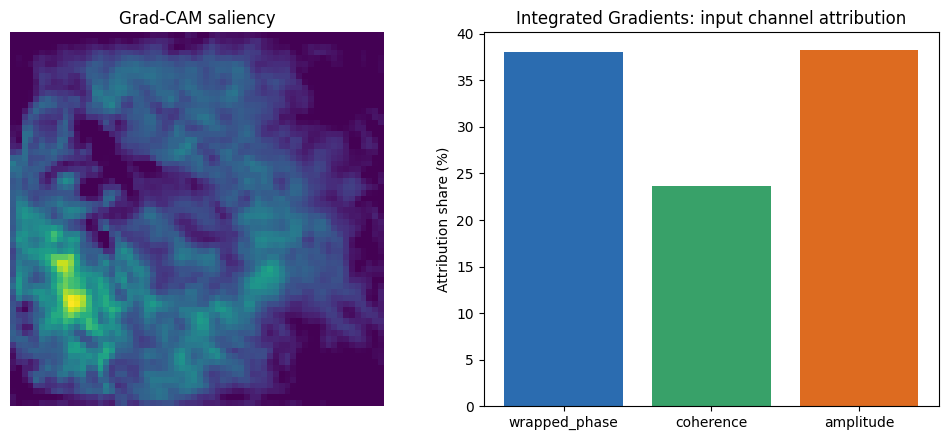

In [8]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].imshow(cam_result.saliency_map, cmap="viridis")
axes[0].set_title("Grad-CAM saliency")
axes[0].axis("off")

names = list(ig_result.channel_importance.keys())
shares = [ig_result.channel_importance[n] * 100 for n in names]
axes[1].bar(names, shares, color=["#2b6cb0", "#38a169", "#dd6b20"])
axes[1].set_ylabel("Attribution share (%)")
axes[1].set_title("Integrated Gradients: input channel attribution")
fig.tight_layout()
plt.show()


## 7. Interactive visualization

In [9]:

fig3d = phase_plots.plot_phase_surface_3d(result.unwrapped_phase, title="Predicted unwrapped phase")
fig3d.show()


## 8. Automated HTML report

In [10]:

report_path = generate_report(
    result,
    out_dir=OUT_DIR / "report",
    true_unwrapped=eval_sample.unwrapped_phase,
    model=model,
    sample_tile_input=x,
    training_history=trainer.visualizer.history,
)
print(f"Report written to: {report_path.resolve()}")


Report written to: /home/claude/pyunwrap/notebooks/nb_full_pipeline/report/report.html


In [11]:

# Render the generated report inline. (If your notebook viewer sandboxes
# iframes, open the file directly: it's a fully self-contained, relative-path
# HTML file plus its assets/ folder.)
display(IFrame(src=str(report_path), width="100%", height=700))



## Summary

This notebook exercised the complete `pyunwrap` chain against real file I/O
(GeoTIFFs in, HTML report out) using the actual package APIs end to end:

`InSARSyntheticGenerator` &rarr; `preprocessing.iter_tiles`/`save_tiles_hdf5`
&rarr; `InSARTileDataset` &rarr; `Trainer.fit()` &rarr; `PhaseUnwrapper.unwrap()`
&rarr; `phase_stats.analyze_scene()` / `explainability.grad_cam()` /
`explainability.integrated_gradients()` &rarr;
`phase_plots.plot_phase_surface_3d()` &rarr; `report_generator.generate_report()`.

For a production run, swap in a real trained checkpoint (`torch.load(...,
map_location=...)` into `model.load_state_dict(...)`), real Sentinel-1-derived
GeoTIFFs, and larger tile sizes (e.g. 512 with 64px overlap, both multiples
of the encoder's stride-32 -- see `PhaseUnwrapper.unwrap`'s docstring).
